In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/pqrd_consolidado.csv')

# Orden cronológico correcto de meses (no alfabético)
orden_meses = ["ENE","FEB","MAR","ABR","MAY","JUN","JUL","AGO","SEP","OCT","NOV","DIC"]
df['mes'] = pd.Categorical(df['mes'], categories=orden_meses, ordered=True)
df = df.sort_values(['anio','mes']).reset_index(drop=True)

df.head()

,anio,mes,tabla_origen,categoria,valor
0,2021,ENE,capital_departamento,MEDELLIN,6098
1,2021,ENE,departamento,ANTIOQUIA,10612
2,2021,ENE,motivo_especifico_legacy_2021_2023,FALTA DE OPORTUNIDAD EN LA ASIGNACIÓN DE CITAS...,9547
3,2021,ENE,motivo_especifico_legacy_2021_2023,FALTA DE OPORTUNIDAD EN LA ENTREGA DE MEDICAME...,2881
4,2021,ENE,motivo_especifico_legacy_2021_2023,DEMORA DE LA PROGRAMACIÓN DE EXÁMENES DE LABOR...,2508


In [3]:
import os
os.makedirs('../reports/figures', exist_ok=True)

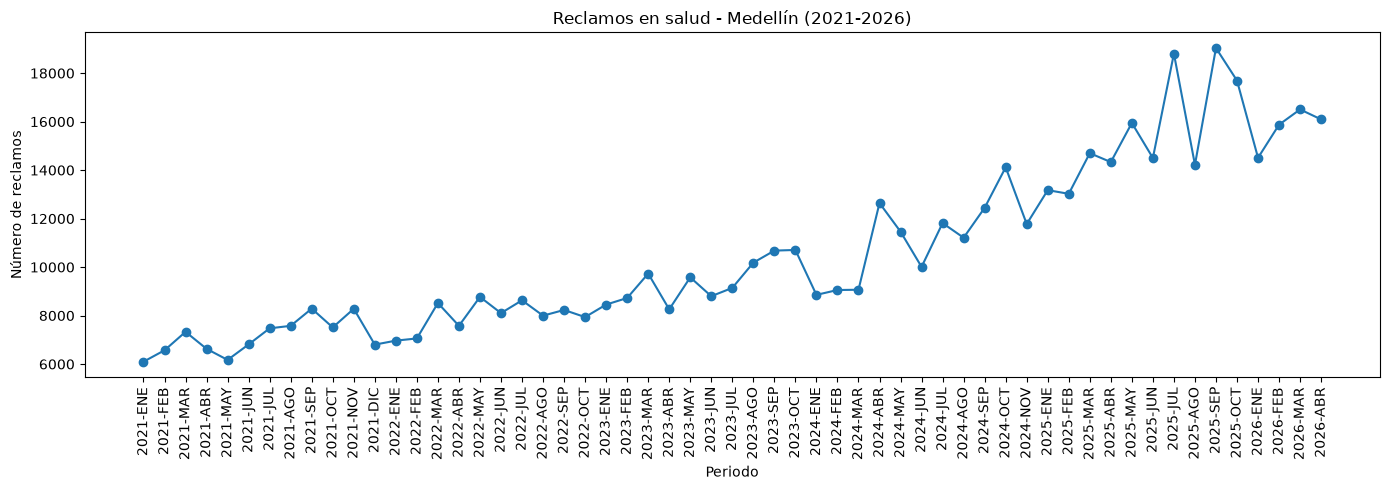

,anio,mes,valor
0,2021,ENE,6098
13,2021,FEB,6569
26,2021,MAR,7330
39,2021,ABR,6628
52,2021,MAY,6172
65,2021,JUN,6811
78,2021,JUL,7475
91,2021,AGO,7577
104,2021,SEP,8287
117,2021,OCT,7512


In [4]:
import os
os.makedirs('../reports/figures', exist_ok=True)

medellin = df[df['categoria']=='MEDELLIN'].copy()
medellin['periodo'] = medellin['anio'].astype(str) + '-' + medellin['mes'].astype(str)

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(medellin['periodo'], medellin['valor'], marker='o')
ax.set_title('Reclamos en salud - Medellín (2021-2026)')
ax.set_xlabel('Periodo')
ax.set_ylabel('Número de reclamos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../reports/figures/medellin_evolucion.png')
plt.show()

medellin[['anio','mes','valor']]

categoria
NEGACIÓN EN LA ASIGNACIÓN DE CITAS O CONSULTAS                  831271
FALTA DE OPORTUNIDAD EN LAS CITAS O CONSULTAS                   743300
NEGACIÓN PARA LA ENTREGA DE TECNOLOGÍAS EN SALUD Y/O DE OTRO    690443
FALTA DE OPORTUNIDAD EN LA ATENCIÓN EN OTROS SERVICIOS DE SA    487786
FALTA DE OPORTUNIDAD EN LA ENTREGA O ENTREGA INCOMPLETA DE T    376330
NEGACIÓN EN LA ATENCIÓN EN OTROS SERVICIOS DE SALUD             342419
FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE OTROS SERVICIOS D    282850
FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TECNOLOGÍAS EN SA    172845
FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE CITAS DE CONSULTA    148395
FALTA DE OPORTUNIDAD EN EL PROCESO DE REFERENCIA Y CONTRARRE     86977
Name: valor, dtype: int64


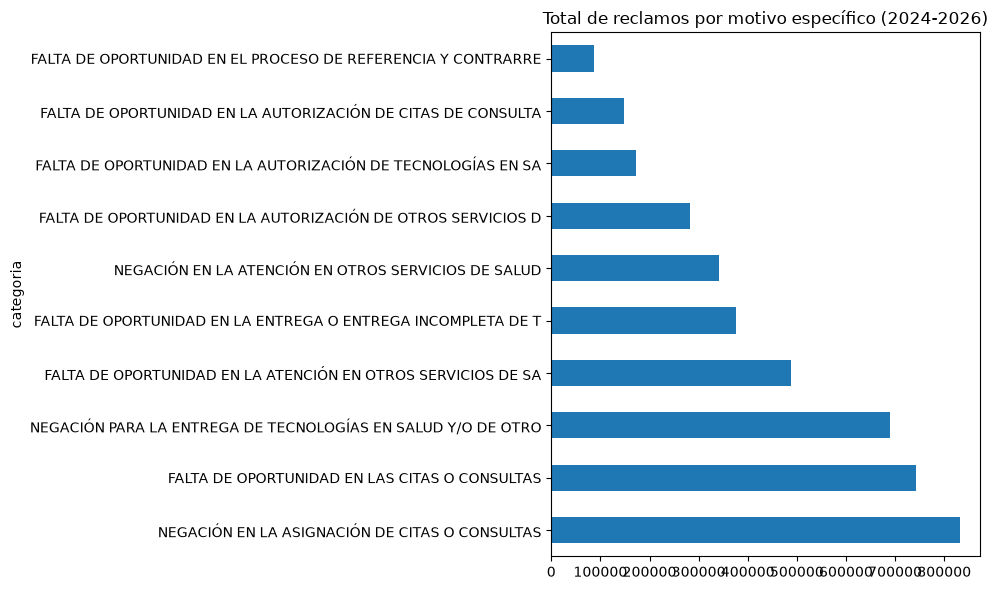

In [5]:
motivos_recientes = df[df['tabla_origen']=='motivo_especifico_2024_2026']
ranking = motivos_recientes.groupby('categoria')['valor'].sum().sort_values(ascending=False)
print(ranking)

ranking.plot(kind='barh', figsize=(10,6), title='Total de reclamos por motivo específico (2024-2026)')
plt.tight_layout()
plt.savefig('../reports/figures/ranking_motivos.png')
plt.show()

In [6]:
# Proporción nacional de cada motivo, por mes (2024-2026, taxonomía consistente)
motivos = df[df['tabla_origen']=='motivo_especifico_2024_2026'].copy()

total_nacional_mes = motivos.groupby(['anio','mes'])['valor'].transform('sum')
motivos['proporcion'] = motivos['valor'] / total_nacional_mes

# Total de reclamos en Medellín, por mes (mismo período 2024-2026)
medellin_total = medellin[medellin['anio']>=2024][['anio','mes','valor']].rename(
    columns={'valor':'total_medellin'})

# Aplicar la proporción nacional al total de Medellín
estimado = motivos.merge(medellin_total, on=['anio','mes'], how='inner')
estimado['reclamos_estimados_medellin'] = estimado['proporcion'] * estimado['total_medellin']

# Guardar el dataset final para modelado
import os
os.makedirs('../data/processed', exist_ok=True)
estimado[['anio','mes','categoria','proporcion','total_medellin','reclamos_estimados_medellin']].to_csv(
    '../data/processed/medellin_motivos_estimados.csv', index=False)

estimado[['anio','mes','categoria','reclamos_estimados_medellin']].sort_values(
    ['anio','mes','reclamos_estimados_medellin'], ascending=[True,True,False])

,anio,mes,categoria,reclamos_estimados_medellin
1,2024,ENE,NEGACIÓN EN LA ASIGNACIÓN DE CITAS O CONSULTAS,2183.663762
2,2024,ENE,FALTA DE OPORTUNIDAD EN LAS CITAS O CONSULTAS,1352.640523
0,2024,ENE,NEGACIÓN PARA LA ENTREGA DE TECNOLOGÍAS EN SAL...,1165.600581
5,2024,ENE,NEGACIÓN EN LA ATENCIÓN EN OTROS SERVICIOS DE ...,1005.569354
3,2024,ENE,FALTA DE OPORTUNIDAD EN LA ATENCIÓN EN OTROS S...,922.154684
...,...,...,...,...
244,2026,ABR,FALTA DE OPORTUNIDAD EN LA ENTREGA O ENTREGA I...,1171.186010
246,2026,ABR,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE OTR...,986.207541
247,2026,ABR,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TEC...,718.505199
248,2026,ABR,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE CIT...,537.752127


In [7]:
import numpy as np

df_modelo = pd.read_csv('../data/processed/medellin_motivos_estimados.csv')

orden_meses = ["ENE","FEB","MAR","ABR","MAY","JUN","JUL","AGO","SEP","OCT","NOV","DIC"]
df_modelo['mes'] = pd.Categorical(df_modelo['mes'], categories=orden_meses, ordered=True)
df_modelo = df_modelo.sort_values(['categoria','anio','mes']).reset_index(drop=True)

# Variación mes a mes (%) por motivo
df_modelo['variacion_pct'] = df_modelo.groupby('categoria')['reclamos_estimados_medellin'].pct_change() * 100

# Promedio móvil de 3 meses por motivo
df_modelo['promedio_movil_3m'] = df_modelo.groupby('categoria')['reclamos_estimados_medellin'] \
    .transform(lambda x: x.rolling(3, min_periods=1).mean())

# Z-score respecto al histórico de CADA motivo (detección de anomalías simple)
media_motivo = df_modelo.groupby('categoria')['reclamos_estimados_medellin'].transform('mean')
std_motivo = df_modelo.groupby('categoria')['reclamos_estimados_medellin'].transform('std')
df_modelo['z_score'] = (df_modelo['reclamos_estimados_medellin'] - media_motivo) / std_motivo

# Clasificación de riesgo (umbral simple: z-score > 1.5 = riesgo alto)
df_modelo['nivel_riesgo'] = pd.cut(
    df_modelo['z_score'],
    bins=[-np.inf, 0, 1.5, np.inf],
    labels=['bajo', 'medio', 'alto']
)

df_modelo.to_csv('../data/processed/medellin_dataset_modelo.csv', index=False)

# Ver los casos de riesgo alto más recientes
df_modelo[df_modelo['nivel_riesgo']=='alto'].sort_values(['anio','mes'], ascending=False).head(15)

,anio,mes,categoria,proporcion,total_medellin,reclamos_estimados_medellin,variacion_pct,promedio_movil_3m,z_score,nivel_riesgo
24,2026,ABR,FALTA DE OPORTUNIDAD EN EL PROCESO DE REFERENC...,0.032099,16092,516.531247,0.239067,483.179075,2.053124,alto
23,2026,MAR,FALTA DE OPORTUNIDAD EN EL PROCESO DE REFERENC...,0.031223,16504,515.299337,23.363932,468.663552,2.040315,alto
123,2026,MAR,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE TEC...,0.047796,16504,788.831196,5.191508,728.265270,1.734796,alto
21,2026,ENE,FALTA DE OPORTUNIDAD EN EL PROCESO DE REFERENC...,0.032599,14509,472.984675,12.167101,441.535380,1.600333,alto
70,2025,OCT,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE CIT...,0.036915,17694,653.168329,-7.606517,632.545767,1.822491,alto
195,2025,OCT,NEGACIÓN EN LA ASIGNACIÓN DE CITAS O CONSULTAS,0.202219,17694,3578.068413,-3.449776,3347.463117,2.128777,alto
220,2025,OCT,NEGACIÓN EN LA ATENCIÓN EN OTROS SERVICIOS DE ...,0.085421,17694,1511.442328,-2.312042,1375.359226,2.169348,alto
44,2025,SEP,FALTA DE OPORTUNIDAD EN LA ATENCIÓN EN OTROS S...,0.121967,19037,2321.884641,35.474894,2080.619700,2.023833,alto
69,2025,SEP,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE CIT...,0.037135,19037,706.941991,31.517490,629.188853,2.402048,alto
94,2025,SEP,FALTA DE OPORTUNIDAD EN LA AUTORIZACIÓN DE OTR...,0.069951,19037,1331.663449,28.639300,1234.408210,2.266842,alto
